Testing for a missing group of factors in Saarelma et al., 2023

Equation 15 in Saarelma et al., 2023 reads:
$$
\frac{d}{dx}
\left[
\langle |\nabla r|^2 \rangle \,
D_{\mathrm{ped}}
\frac{dn_e}{dx}
\right]
=
- n_e S_i
\left\{
-
D_{\mathrm{ped}}
\left(
\frac{dn_e}{dx}
-
\left.
\frac{dn_e}{dx}
\right|_{x=-\infty}
\right)
+
\left[
1
-
\frac{|Vcf|\, f_{FC}(S_i + Scx/2)}
{|Vcx|\, f_{CX}(S_i + Scx)}
\right]
\langle n_{FC} \rangle(0)
\exp
\left[
\int_0^x
\frac{
n_e(x')
(S_i + Scx)
}{
f_{FC}\, |Vfc|
}
\, dx'
\right]
\right\}.
$$

I believe it should read:
$$
\frac{d}{dx}
\left[
\langle |\nabla r|^2 \rangle \,
D_{\mathrm{ped}}
\frac{dn_e}{dx}
\right]
=
- n_e S_i
\left\{
-
\frac{\langle |\nabla r|^2 \rangle D_{\mathrm{ped}}}
{|Vcx|\, f_{CX}}
\left(
\frac{dn_e}{dx}
-
\left.
\frac{dn_e}{dx}
\right|_{x=-\infty}
\right)
+
\left[
1
-
\frac{|Vcf|\, f_{FC}(S_i + Scx/2)}
{|Vcx|\, f_{CX}(S_i + Scx)}
\right]
\langle n_{FC} \rangle(0)
\exp
\left[
\int_0^x
\frac{
n_e(x')
(S_i + Scx)
}{
f_{FC}\, |Vfc|
}
\, dx'
\right]
\right\}.
$$

My version has units that line up with the remainder of the equation. There is a missing factor of [m*s] I believe.

In this document, we will test my implementation of this model with both methods.

First, see the parameter space we would like to test using my version of the model (looking for a decently converged result)

In [4]:
import sys
import gc
from pathlib import Path
import csv
import os


# Put repo root on path so `src` is importable (parent of this notebook's folder).
ROOT = Path.cwd()
ROOT = ROOT.parent.parent
sys.path.insert(0, str(ROOT))

from src.solver import saarelma_connor
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Input files
mhd_fp = '/Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/PT_Hmode/g150840.03000' # filepath to MHD paramter file
kprof_fp = '/Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/PT_Hmode/p150840.03000' # filepath to kinetic paramter file

# Scan size
N = 5

# Scan parameters
# alpha_crits = np.linspace(0.01, 2.0, 3)
# C_KBMs = np.linspace(0.01, 0.9, 3)
# De_chie_etgs = np.linspace(0.01, 0.9, 3)
# nFC_x0s = np.linspace(5e14, 9e15, 3)
alpha_crits = np.logspace(-2, 1.5, N)
C_KBMs = np.logspace(-1, 1.5, N)
De_chie_etgs = np.logspace(-1, 1.5, N)
nFC_x0s = np.logspace(14.5, 16.5, N)
# Inner-boundary threshold (used to compute the OUTER limit of the
# psi_N_inner_boundary scan range; smaller -> outer limit further inward).
boundary_threshold = 1e-4
# Number of points to sample between (slope-zero inner limit) and (outer limit).
n_psi_inner_pts = N
# Safety margin for the inner limit: place the deepest valid boundary at
# psi_N where dne/dx = safety_margin * min(dne/dx) rather than exactly 0.
psi_inner_safety_margin = 0.01

# Static parameters
P_tot_e = 5e6 # W, total heating power given to electrons (can be assumed to be half the total heating power according to S. Saarelma et al 2023 Nucl. Fusion 63 052002), will be read from TokTox
solve_res = 100


In [6]:
# Output data and files
success_fp = 'success_me.txt'
failure_fp = 'failure_me.txt'
error_messages_fp = 'error_messages_me.txt'
with open(success_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner\n")
with open(failure_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner\n")
with open(error_messages_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner, message\n")
ne_success_fp = 'scan_success_me'
verbose = False

In [7]:
# Build the model once — the expensive flux-surface-averaging and equilibrium
# loading runs here only, not inside the loop.
base_model = saarelma_connor(
        P_tot_e     = P_tot_e,
        alpha_crit  = round(float(alpha_crits[0]), 3),
        C_KBM       = round(float(C_KBMs[0]), 3),
        De_chie_etg = round(float(De_chie_etgs[0]), 3),
        nFC_x0      = round(float(nFC_x0s[0]), 3),
        mhd_fp      = mhd_fp,
        kprof_fp    = kprof_fp,
        verbose     = False,
        nFC_threshold = boundary_threshold, # used initially to compute the outer limit of the boundary range
        nCX_threshold = boundary_threshold, # used initially to compute the outer limit of the boundary range
        error_check = False, # use my version of themodel
)
print("Base model built — starting scan.")

# Delete all files in ne_success_fp
for file in os.listdir(ne_success_fp):
    os.remove(os.path.join(ne_success_fp, file))

# run scan: for each (alpha_crit, C_KBM, De_chie_etg, nFC_x0) we recompute
# the valid range of psi_N_inner_boundary from the slope-zero inner limit to
# the nFC/nCX-threshold outer limit, then sample n_psi_inner_pts boundaries.
i=0
for alpha_crit in alpha_crits:
        j=0
        for C_KBM in C_KBMs:
                k=0
                for De_chie_etg in De_chie_etgs:
                        l=0
                        for nFC_x0 in nFC_x0s:
                                ac = round(float(alpha_crit), 3)
                                ck = round(float(C_KBM), 3)
                                de = round(float(De_chie_etg), 3)
                                nf = round(float(nFC_x0), 3)

                                # Step 1: apply free params with adaptive thresholds active so
                                # inner_boundary_limits can compute the outer limit correctly.
                                base_model.update_free_params(
                                        alpha_crit    = ac,
                                        C_KBM         = ck,
                                        De_chie_etg   = de,
                                        nFC_x0        = nf,
                                        nFC_threshold = boundary_threshold,
                                        nCX_threshold = boundary_threshold,
                                )
                                try:
                                        psi_inner_lim, psi_outer_lim = base_model.inner_boundary_limits(
                                                outer_threshold = boundary_threshold,
                                                x_res           = solve_res,
                                        )
                                except Exception as e:
                                        # Range computation failed; log and skip this combination.
                                        with open(error_messages_fp, 'a') as f:
                                                f.write(f"{ac}, {ck}, {de}, {nf}, range_failed, {e}\n")
                                        continue

                                if psi_inner_lim >= psi_outer_lim:
                                        psi_scan = np.array([psi_outer_lim])
                                else:
                                        psi_scan = np.linspace(psi_inner_lim, psi_outer_lim, n_psi_inner_pts)

                                m=0
                                for psi_b in psi_scan:
                                        psi_val = round(float(psi_b), 4)
                                        try:
                                                base_model.update_free_params(
                                                        alpha_crit            = ac,
                                                        C_KBM                 = ck,
                                                        De_chie_etg           = de,
                                                        nFC_x0                = nf,
                                                        psi_N_inner_boundary  = psi_val,
                                                )
                                                base_model.solve(x_res=solve_res)
                                        except Exception as e: # run fails
                                                with open(failure_fp, 'a') as f:
                                                        f.write(f"{ac}, {ck}, {de}, {nf}, {psi_val:.4f}\n")
                                                with open(error_messages_fp, 'a') as f:
                                                        f.write(f"{ac}, {ck}, {de}, {nf}, {psi_val:.4f}, {e}\n")
                                                m+=1
                                        else: # run works
                                                with open(success_fp, 'a') as f:
                                                        f.write(f"{ac}, {ck}, {de}, {nf}, {psi_val:.4f}\n")
                                                np.save(f'{ne_success_fp}/ne_a{ac}_C{ck}_D{de}_n{nf}_b{psi_val:.4f}', base_model.sol, allow_pickle=True)
                                                m+=1

                                l+=1
                                # print(f"Completed {l} of {len(nFC_x0s)} nFC_x0s  [psi_N range: {psi_inner_lim:.3f}..{psi_outer_lim:.3f}]") # progress logging
                        k+=1
                        # print(f"Completed {k} of {len(De_chie_etgs)} De_chie_etgs") # progress logging
                j+=1
                # print(f"Completed {j} of {len(C_KBMs)} C_KBMs") # progress logging
        i+=1
        print(f"Completed {i} of {len(alpha_crits)} alpha_crits") # progress logging

Base model built — starting scan.
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_inner_boundary: 0.8906
x_inner: -0.0400 m
psi_N_

Experimental p-file peak n_e: 8.237e+19 m^-3
rank  alpha_crit     C_KBM  De_chie_etg        nFC_x0   psi_inner       L2 (m^-3)
---------------------------------------------------------------------------------
   1       0.075       0.1          0.1      3.16e+16      0.8906       2.890e+19
   2        0.01       0.1          0.1      3.16e+16      0.8906       2.892e+19
   3        4.22      31.6          0.1      3.16e+16      0.8906       2.900e+19
   4        4.22      31.6          0.1      3.16e+16      0.9023       2.970e+19
   5        4.22      31.6        0.422      3.16e+16      0.8984       2.974e+19
   6        4.22      31.6          0.1      3.16e+16      0.9141       2.978e+19
   7        4.22       7.5          0.1         1e+16      0.8945       2.990e+19
   8        4.22      31.6          0.1      3.16e+16      0.9258       2.990e+19
   9        4.22      31.6        0.422      3.16e+16      0.8965       2.997e+19
  10        4.22       7.5          0.1         1e+16

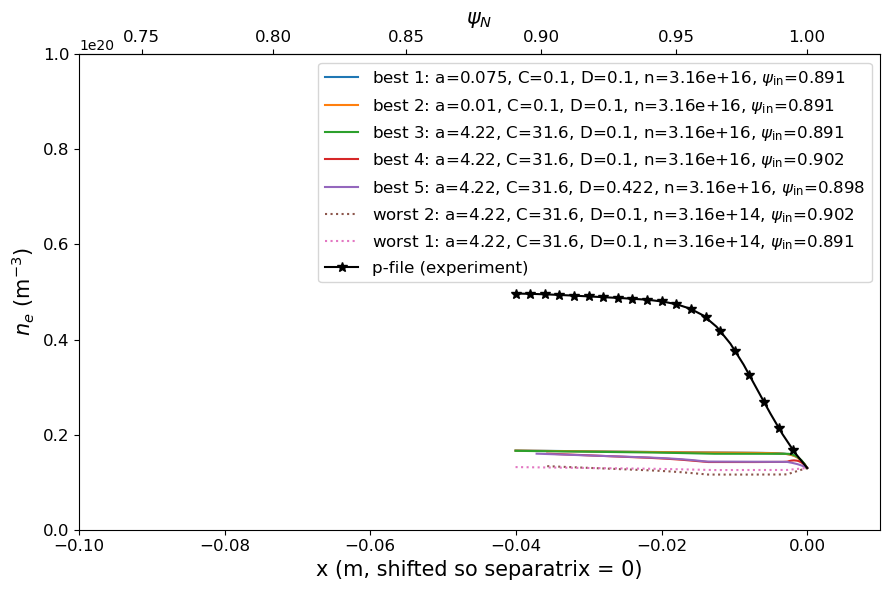

In [8]:
# Determine which combination of parameters in all the successful runs best matches the initial p file's pedestal density (L2 distance of each point)

import re
from pathlib import Path
from scipy.interpolate import interp1d

# 1. Peak density from the experimental p-file (m^-3)
def read_pfile_ne(path):
    psi_arr, ne_arr = [], []
    in_ne_block = False
    with open(path) as f:
        for line in f:
            if '3 N Z A' in line:
                break
            if line.startswith('201'):
                in_ne_block = 'ne(10^20/m^3)' in line
                continue
            if in_ne_block:
                psi, val, _ = line.split()
                psi_arr.append(float(psi))
                ne_arr.append(float(val))
    return np.array(psi_arr), np.array(ne_arr) * 1e20  # m^-3

psi_pfile, ne_pfile = read_pfile_ne(kprof_fp)
peak_pfile = ne_pfile.max()
print(f"Experimental p-file peak n_e: {peak_pfile:.3e} m^-3")

# Build psi_N -> x mapping once (reused in cell 8)
ref = saarelma_connor(
    P_tot_e=P_tot_e,
    alpha_crit=alpha_crits[0],
    C_KBM=C_KBMs[0],
    De_chie_etg=De_chie_etgs[0],
    nFC_x0=nFC_x0s[0],
    mhd_fp=mhd_fp,
    kprof_fp=kprof_fp,
    verbose=False,
)
psi_to_x = interp1d(ref.psi_N_pres, ref.r_psi - ref.r_psi[-1],
                    kind='linear', bounds_error=False, fill_value='extrapolate')
# Inverse map for the secondary axis (x in meters -> psi_N).
x_to_psi = interp1d(ref.r_psi - ref.r_psi[-1], ref.psi_N_pres,
                    kind='linear', bounds_error=False, fill_value='extrapolate')

# Experimental ne mapped to x
x_pfile = psi_to_x(psi_pfile)

# 2. For each successful run, load the saved sol and compute its peak n_e
scan_dir = Path(ne_success_fp)
pattern = re.compile(r"_([a-zA-Z])([\d.eE+-]+)")


# Pedestal grid (psi_N = 0.85 .. 1.0); psi_to_x was built in cell 7.
# L2 is still scored on this common grid so the ranking is comparable across
# runs that solved on different x domains.
psi_ped = np.linspace(0.85, 1.0, 200)
x_ped = psi_to_x(psi_ped)  # m, shifted so separatrix = 0

# Experimental ne on the pedestal grid (m^-3)
ne_pfile_ped = interp1d(psi_pfile, ne_pfile, kind='linear',
                        bounds_error=False, fill_value='extrapolate')(psi_ped)
# Experimental ne on each run's own x domain is computed inside the loop
ne_pfile_of_x = interp1d(x_pfile, ne_pfile, kind='linear',
                         bounds_error=False, fill_value='extrapolate')

# Compare each successful run's predicted profile to the experimental profile
results_l2 = []
for npy_path in scan_dir.glob("ne_*.npy"):
    pairs = pattern.findall(npy_path.stem)
    params = {letter: float(num) for letter, num in pairs}
    sol = np.load(npy_path, allow_pickle=True).item()
    ne_pred_ped = interp1d(sol.x, sol.y[0], kind='linear',
                           bounds_error=False, fill_value='extrapolate')(x_ped)
    l2 = np.sqrt(np.mean((ne_pred_ped - ne_pfile_ped) ** 2))  # RMS in m^-3
    results_l2.append({
        'alpha_crit':  params.get('a'),
        'C_KBM':       params.get('C'),
        'De_chie_etg': params.get('D'),
        'nFC_x0':      params.get('n'),
        'psi_inner':   params.get('b'),  # explicit psi_N_inner_boundary
        'l2':          l2,
        'sol_x':       sol.x,        # solver's own domain
        'sol_ne':      sol.y[0],     # solver's own profile
    })

results_l2.sort(key=lambda r: r['l2'])

header = (f"{'rank':>4}  {'alpha_crit':>10}  {'C_KBM':>8}  {'De_chie_etg':>11}  "
          f"{'nFC_x0':>12}  {'psi_inner':>10}  {'L2 (m^-3)':>14}")
print(header)
print("-" * len(header))
for rank, r in enumerate(results_l2, start=1):
    psi_str = f"{r['psi_inner']:.4f}" if r['psi_inner'] is not None else "n/a"
    print(f"{rank:>4}  {r['alpha_crit']:>10.3g}  {r['C_KBM']:>8.3g}  "
          f"{r['De_chie_etg']:>11.3g}  {r['nFC_x0']:>12.3g}  {psi_str:>10}  {r['l2']:>14.3e}")

# Plot top 5 best (solid), worst 2 (dotted) — each on its own solver domain.
# p-file (line + stars) is plotted on the union of all model domains.
def _label(r):
    psi_str = f"{r['psi_inner']:.3f}" if r['psi_inner'] is not None else "n/a"
    return (f"a={r['alpha_crit']:.3g}, C={r['C_KBM']:.3g}, "
            f"D={r['De_chie_etg']:.3g}, n={r['nFC_x0']:.3g}, "
            r"$\psi_{\mathrm{in}}$=" + psi_str)

fig, ax = plt.subplots(figsize=(9, 6))
for i, r in enumerate(results_l2[:5]):
    ax.plot(r['sol_x'], r['sol_ne'], '-', label=f"best {i+1}: {_label(r)}")
for i, r in enumerate(results_l2[-2:]):
    ax.plot(r['sol_x'], r['sol_ne'], ':', label=f"worst {2-i}: {_label(r)}")

# Use the widest model domain among the plotted runs as the experimental x range
plotted = results_l2[:5] + results_l2[-2:]
x_lo = min(r['sol_x'].min() for r in plotted)
x_hi = max(r['sol_x'].max() for r in plotted)
x_exp = np.linspace(x_lo, x_hi, 400)
ax.plot(x_exp, ne_pfile_of_x(x_exp), '-*', color='black', markevery=20,
        markersize=7, label='p-file (experiment)')

ax.set_xlabel('x (m, shifted so separatrix = 0)', fontsize=15)
ax.set_ylabel(r'$n_e$ (m$^{-3}$)', fontsize=15)
ax.legend(fontsize=12, loc='best')
ax.tick_params(axis='both', labelsize=12)
ax.set_xlim(-0.1, 0.01)
ax.set_ylim(0,1e20)
# Secondary x-axis on top showing psi_N (uses the bidirectional x<->psi_N map
# built in cell 7).
secax = ax.secondary_xaxis('top', functions=(x_to_psi, psi_to_x))
secax.set_xlabel(r'$\psi_N$', fontsize=15)
secax.tick_params(axis='x', labelsize=12)
plt.tight_layout()
plt.show()

Samuli

In [ ]:
# Output data and files
success_fp = 'success_Samuli.txt'
failure_fp = 'failure_Samuli.txt'
error_messages_fp = 'error_messages_Samuli.txt'
with open(success_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner\n")
with open(failure_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner\n")
with open(error_messages_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner, message\n")
ne_success_fp = 'scan_success_Samuli'
verbose = False